<a href="https://colab.research.google.com/github/elavarasan2706m-boop/Stock-Trading-With-LSTM-And-RL/blob/main/data_loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [1]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [3]:
# TODO 1.1 — Define directory paths and create them on disk

BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Create directories if they don't exist
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : /content/data/raw
PROCESSED_DIR: /content/data/processed


In [4]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE = '2015-01-01'
END_DATE   = None  # Defaults to today inside yfinance

# Load the market symbols as described in your guidelines
MARKET_SYMBOLS = {
    'india':  ['^NSEI', '^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS'],
    'us':     ['^GSPC', '^IXIC', 'SPY', 'AAPL', 'MSFT', 'NVDA', 'TSLA'],
    'crypto': ['BTC-USD', 'ETH-USD'],
    'forex':  ['EURUSD=X', 'JPY=X'],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [5]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'
def safe_symbol(symbol: str) -> str:
    # 1. Remove the index leading carrot '^' if present
    s = symbol.lstrip('^')
    # 2. Replace structural punctuation characters with underscores
    for char in ['.', '-', '=']:
        s = s.replace(char, '_')
    return s

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [6]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function with required flags
    data = yf.download(symbol, start=start, end=end, auto_adjust=False, progress=False)

    # 2. Raise ValueError if data returns empty or structure missing
    if data.empty:
        raise ValueError(f"No data returned from Yahoo Finance for ticker: {symbol}")

    # 3. Flatten MultiIndex column structures if they exist
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # 4. Reset index so 'Date' converts from index into a normal column
    data = data.reset_index()

    # 5. Normalise column names to lower_case and replace spaces with underscores
    data.columns = [str(col).lower().strip().replace(' ', '_') for col in data.columns]

    # 6. Add structural symbol identifier column
    data['symbol'] = symbol

    return data

# Quick test
test_df = download_symbol('SPY')
print("Shape :", test_df.shape)
print("Columns:", test_df.columns.tolist())
test_df.head()

Shape : (2868, 8)
Columns: ['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052628,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541183,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [7]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.

for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
            print(f"Downloading [{market.upper()}] {symbol}...")
            df_symbol = download_symbol(symbol)

            # Form clean filename output path matching required structure
            filename = f"{safe_symbol(symbol)}.csv"
            out_path = RAW_DIR / filename

            # Save raw data without copying the pandas default range index
            df_symbol.to_csv(out_path, index=False)
            print(f" Saved successfully to {out_path}")

        except Exception as e:
            print(f"❌ Error downloading {symbol}: {e}")

 Saved successfully to /content/data/raw/NSEI.csv
 Saved successfully to /content/data/raw/BSESN.csv
 Saved successfully to /content/data/raw/RELIANCE_NS.csv
 Saved successfully to /content/data/raw/TCS_NS.csv
 Saved successfully to /content/data/raw/INFY_NS.csv
 Saved successfully to /content/data/raw/GSPC.csv
 Saved successfully to /content/data/raw/IXIC.csv
 Saved successfully to /content/data/raw/SPY.csv
 Saved successfully to /content/data/raw/AAPL.csv
 Saved successfully to /content/data/raw/MSFT.csv
 Saved successfully to /content/data/raw/NVDA.csv
 Saved successfully to /content/data/raw/TSLA.csv
 Saved successfully to /content/data/raw/BTC_USD.csv
 Saved successfully to /content/data/raw/ETH_USD.csv
 Saved successfully to /content/data/raw/EURUSD_X.csv
 Saved successfully to /content/data/raw/JPY_X.csv


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [8]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.

SYMBOL = 'SPY'
raw_file_path = RAW_DIR / f"{safe_symbol(SYMBOL)}.csv"

# Load data, enforce datetime typing on date, and sort sequentially
df = pd.read_csv(raw_file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2868, 8)
Dtypes:
 date         datetime64[ns]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol               object
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.124969,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052643,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479126,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541229,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514252,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [9]:
# TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close

# Set up a date index temporarily to allow calculations to process smoothly
df_calc = df.set_index('date')
close = df_calc['close']

# Calculate daily price change values
daily_returns = close.pct_change()

mean_daily_return = daily_returns.mean()
daily_std = daily_returns.std()
annualised_vol = daily_std * np.sqrt(252)

# Total Cumulative Return calculation formula using closing prices
total_cumulative_return = (close.iloc[-1] / close.iloc[0]) - 1

# Extract specific all-time high/low parameters
ath_date = close.idxmax()
atl_date = close.idxmin()

print(f"--- Statistics for {SYMBOL} ---")
print(f"Mean Daily Return               : {mean_daily_return:.6f}")
print(f"Daily Volatility (Std Dev)      : {daily_std:.6f}")
print(f"Annualised Volatility           : {annualised_vol:.4%}")
print(f"Total Cumulative Return         : {total_cumulative_return:.2%}")
print(f"All-Time High Date (Close)      : {ath_date.strftime('%Y-%m-%d')} (${close.max():.2f})")
print(f"All-Time Low Date (Close)       : {atl_date.strftime('%Y-%m-%d')} (${close.min():.2f})")

--- Statistics for SPY ---
Mean Daily Return               : 0.000517
Daily Volatility (Std Dev)      : 0.011163
Annualised Volatility           : 17.7214%
Total Cumulative Return         : 268.24%
All-Time High Date (Close)      : 2026-05-29 ($756.48)
All-Time Low Date (Close)       : 2016-02-11 ($182.86)


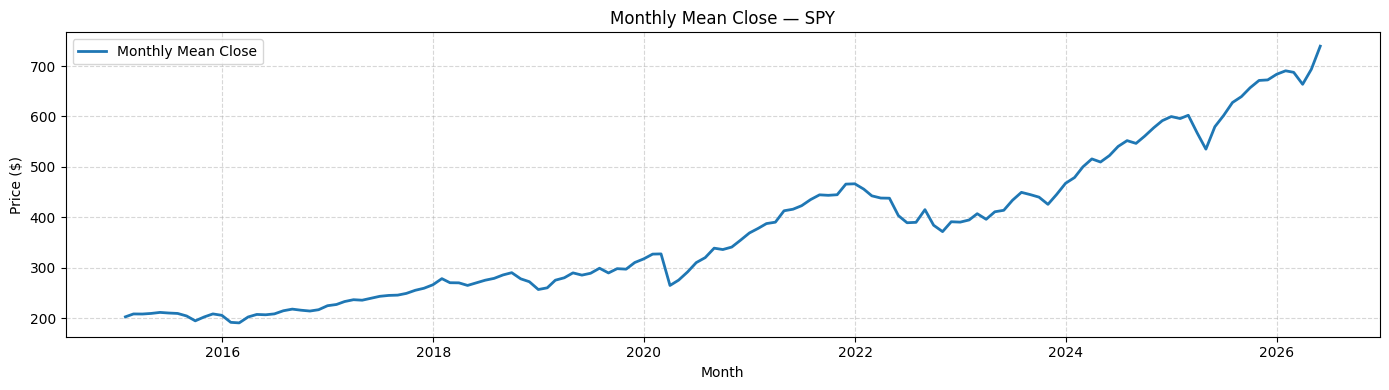

In [10]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

# Ensure index is datetime before resampling ('ME' stands for Monthly End)
df_calc = df.set_index('date')
monthly_close = df_calc['close'].resample('ME').mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_close.index, monthly_close.values, color='tab:blue', linewidth=2, label='Monthly Mean Close')
plt.title(f'Monthly Mean Close — {SYMBOL}')
plt.xlabel('Month')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

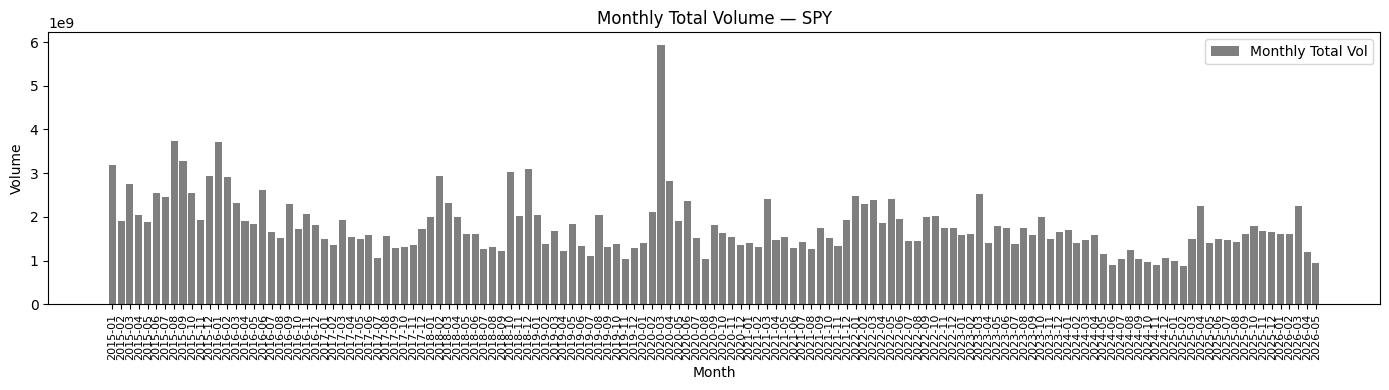

In [11]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

df_calc = df.set_index('date')
monthly_vol = df_calc['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
# Convert timestamps to clean strings for neat bar chart x-axis rendering
plt.bar(monthly_vol.index.strftime('%Y-%m'), monthly_vol.values, color='tab:gray', width=0.8, label='Monthly Total Vol')
plt.title(f'Monthly Total Volume — {SYMBOL}')
plt.xlabel('Month')
plt.ylabel('Volume')

# Rotate labels so they don't overlap if data range is long
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [12]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = {}

for sym in MARKET_SYMBOLS['us']:
    file_path = RAW_DIR / f"{safe_symbol(sym)}.csv"
    if file_path.exists():
        df_sym = pd.read_csv(file_path, parse_dates=['date'])
        # Store close series mapping to date index to handle alignment differences
        us_closes[sym] = df_sym.set_index('date')['close']

# Combine individual series into a single master layout DataFrame
df_us_closes = pd.DataFrame(us_closes)

# Sort ascending chronological order and forward fill gaps (e.g. holiday matching anomalies)
df_us_closes = df_us_closes.sort_index().ffill().bfill()
print("US Closes Combined Matrix Summary Table:")
print(df_us_closes.head())

US Closes Combined Matrix Summary Table:
                  ^GSPC        ^IXIC         SPY       AAPL       MSFT  \
date                                                                     
2015-01-02  2058.199951  4726.810059  205.429993  27.332500  46.759998   
2015-01-05  2020.579956  4652.569824  201.720001  26.562500  46.330002   
2015-01-06  2002.609985  4592.740234  199.820007  26.565001  45.650002   
2015-01-07  2025.900024  4650.470215  202.309998  26.937500  46.230000   
2015-01-08  2062.139893  4736.189941  205.899994  27.972500  47.590000   

               NVDA       TSLA  
date                            
2015-01-02  0.50325  14.620667  
2015-01-05  0.49475  14.006000  
2015-01-06  0.47975  14.085333  
2015-01-07  0.47850  14.063333  
2015-01-08  0.49650  14.041333  


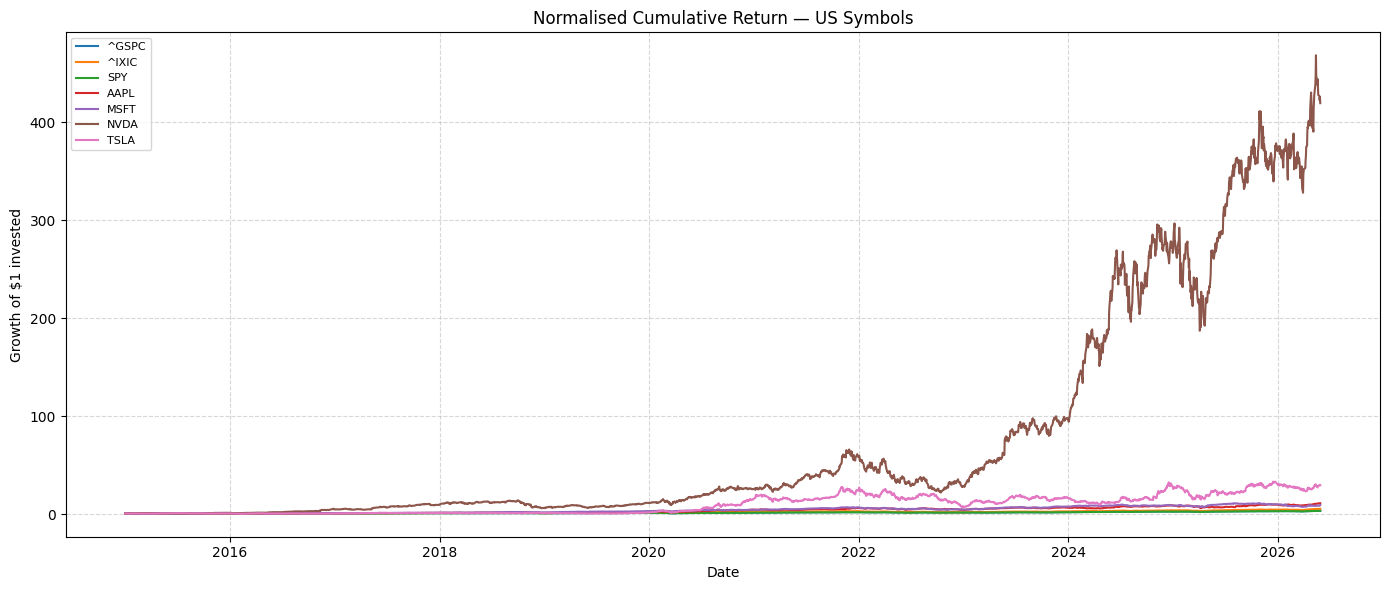

In [13]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
# Performance tracking formula: Divide every price row value by row entry 0
df_us_normalised = df_us_closes / df_us_closes.iloc[0]

plt.figure(figsize=(14, 6))
for col in df_us_normalised.columns:
    plt.plot(df_us_normalised.index, df_us_normalised[col], label=col, linewidth=1.5)

plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested')
plt.xlabel('Date')
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

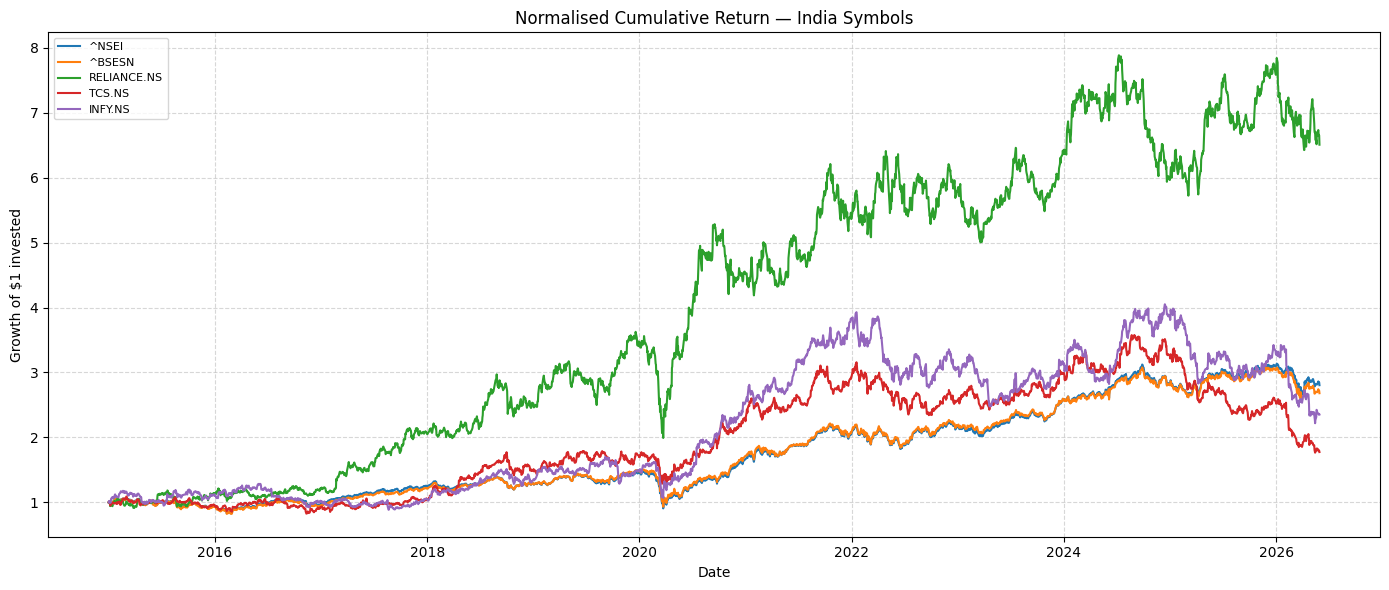

In [14]:
# TODO 5.3 — Repeat for India symbols

india_closes = {}

for sym in MARKET_SYMBOLS['india']:
    file_path = RAW_DIR / f"{safe_symbol(sym)}.csv"
    if file_path.exists():
        df_sym = pd.read_csv(file_path, parse_dates=['date'])
        india_closes[sym] = df_sym.set_index('date')['close']

# Process and merge DataFrame
df_india_closes = pd.DataFrame(india_closes).sort_index().ffill().bfill()

# Normalise growth index values from base 1.0
df_india_normalised = df_india_closes / df_india_closes.iloc[0]

# Generate multi-line comparison visualization
plt.figure(figsize=(14, 6))
for col in df_india_normalised.columns:
    plt.plot(df_india_normalised.index, df_india_normalised[col], label=col, linewidth=1.5)

plt.title('Normalised Cumulative Return — India Symbols')
plt.ylabel('Growth of $1 invested')
plt.xlabel('Date')
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
